# Baseline Model and Results for Art Dataset

In this notebook, we implement a convolutional neural network (CNN) with residuals model to classify images as either 'real' or 'fake' faces.

## Table of Contents
1. [Imports and Setup](#imports-and-setup)
2. [Helper functions](#helper-functions)
3. [Load data](#load-data)
4. [Baseline model and training](#baseline-model-and-training)
6. [Model Evaluation](#model-evaluation)
7. [Performances analysis](#performances-analysis)

### Imports and Setup

In [40]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 28.9 MB/s eta 0:00:0000:01:00:01


In [1]:

import math
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Add, Flatten)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc,ConfusionMatrixDisplay, RocCurveDisplay
import numpy as np
import os
import seaborn as sns
import cv2



2025-04-27 23:53:33.780701: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-27 23:53:33.780738: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-27 23:53:33.781380: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 23:53:33.786274: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#CHECK GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#### CONSTANTS ###
train_data_path = "../dataset_train"
test_data_path = "../dataset_test"
weigths_path = "../weights"

### Helper functions

We've added our data directly in the cluster repository under the folder dataset_train and dataset_test. The following helpers functions help us to load, process and clean the data directly.

In [ ]:
### HELPER FUNCTIONS ###

def load_image_dataset(data_path, category='art', batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Load images from the specified directory.
    
    Expects the following structure:
       data_path/category/real/...
       data_path/category/fake/...
    
    Parameters:
        data_path (str): Base path for training or test dataset (e.g., "dataset_train" or "dataset_test").
        category (str): Specific category folder (default is "art").
        batch_size (int): Number of images per batch.
        img_size (tuple): Target image size.
        
    Returns:
        A tf.data.Dataset object ready for training/testing.
    """
    dataset_dir = f"{data_path}/{category}"
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_dir,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )
    class_names = dataset.class_names

    if subset_ratio < 1.0:
        total_batches = tf.data.experimental.cardinality(dataset).numpy()
        subset_batches = int(total_batches * subset_ratio)
        dataset = dataset.take(subset_batches)

    return dataset, class_names

def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    
    Parameters:
        dataset (tf.data.Dataset): A TensorFlow dataset where each element is a (image, label) pair.
        
    Returns:
        A new tf.data.Dataset with the images scaled to [0, 1].
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

# VISUALIZE TRAINING DATA
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')

    # loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()
    

def plot_gradcam(model, image, class_index, last_conv_layer_name, alpha=0.4):
    """
    Generates and plots a Grad-CAM heatmap for a given image and class.

    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels). 
               The image should be preprocessed (e.g., normalized) as needed.
        class_index: Integer index of the target class to visualize.
        last_conv_layer_name: String, name of the last convolutional layer in the model.
        alpha: Float, transparency factor for the heatmap overlay.
    """
    img_tensor = np.expand_dims(image, axis=0)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(np.expand_dims(
        heatmap, axis=-1), (image.shape[0], image.shape[1])).numpy()
    heatmap = np.squeeze(heatmap)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image)
    ax[0].set_title('Original imege')
    ax[0].axis('off')
    ax[1].imshow(image)
    ax[1].imshow(heatmap, cmap='jet', alpha=alpha)
    ax[1].set_title('Grad-CAM heatmap')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()
    
def compute_saliency_map(model, image, target_class=0):
    """
    Computes the saliency map for the given image and target class.
    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels).
               Assumed to be preprocessed (e.g., normalized) as required by the model.
        target_class: Integer index for the target class (0 for 'fake', 1 for 'real').
    Returns:
        A NumPy array representing the saliency map.
    """
    img_tensor = tf.expand_dims(image, axis=0)
    img_tensor = tf.cast(img_tensor, tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        score = preds if target_class == 1 else 1 - preds
        
    grads = tape.gradient(score, img_tensor)
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    return saliency.numpy()


def display_saliency_map(model, image, target_class=0):
    """
    Computes and displays the saliency map alongside the original image.
    
    Args:
        model: Trained Keras model.
        image: A single input image as a NumPy array.
        target_class: The index of the target class.
    """
    saliency = compute_saliency_map(model, image, target_class)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency map")
    plt.axis("off")

    plt.show()


def get_predictions_and_labels(dataset, model):
    y_pred = []
    y_true = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        pred_classes = (predictions > 0.5).astype(int)
        
        y_pred.extend(pred_classes.flatten())
        y_true.extend(labels.numpy())
    
    return np.array(y_pred), np.array(y_true)


def get_probabilities_and_labels(dataset, model):
    y_prob = []
    y_true = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        
        y_prob.extend(predictions.flatten())
        y_true.extend(labels.numpy())
    
    return np.array(y_prob), np.array(y_true)

def get_sample_images(dataset, num_samples=5):
    """
    Get sample images from dataset for visualization
    """
    sample_images = []
    sample_labels = []
    class_counts = {0: 0, 1: 0}  
    
    for images, labels in dataset:
        for i in range(len(images)):
            img = images[i].numpy()
            label = int(labels[i].numpy())
            
            if class_counts[label] < num_samples:
                sample_images.append(img)
                sample_labels.append(label)
                class_counts[label] += 1
        
        if min(class_counts.values()) >= num_samples:
            break
    
    return sample_images, sample_labels

def visualize_single_image(model, img, last_conv_layer_name, actual_class):
    """
    Visualize a single image with both Grad-CAM and Saliency Map
    """
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    ax[0].imshow(img)
    ax[0].set_title(f"{'Real' if actual_class==1 else 'Fake'} Art")
    ax[0].axis('off')
    
    # Saliency Map
    saliency = compute_saliency_map(model, img, target_class=actual_class)
    ax[1].imshow(saliency, cmap='jet')
    ax[1].set_title("Saliency Map")
    ax[1].axis('off')
    
    # Grad-CAM
    ax[2].imshow(img)
    
    # Compute Grad-CAM
    img_tensor = np.expand_dims(img, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        pred_prob = predictions[0][0].numpy()
        pred_class = 1 if pred_prob > 0.5 else 0
        loss = predictions[:, 0] if actual_class == 0 else 1 - predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Overlay heatmap
    ax[2].imshow(heatmap, cmap='jet', alpha=0.4)
    ax[2].set_title(f"Grad-CAM (Pred: {'Real' if pred_class==1 else 'Fake'}, {pred_prob:.2f})")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()


def find_interesting_examples(dataset, model, num_samples=5):
    """
    Find examples where the model is very confident or misclassified
    Used for GRAD-Cam and Saliency map
    """
    correct_confident = []
    incorrect = []
    unsure = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        
        for i in range(len(images)):
            img = images[i].numpy()
            true_label = int(labels[i].numpy())
            pred_prob = predictions[i][0]
            pred_label = 1 if pred_prob > 0.5 else 0
            
            if pred_label == true_label:
                if pred_prob > 0.95 or pred_prob < 0.05:  # this is the confident prediction
                    correct_confident.append((img, true_label, pred_prob))
            else:  # these are the misclassified
                incorrect.append((img, true_label, pred_prob))
            
            # unsure predictions
            if 0.4 < pred_prob < 0.6:
                unsure.append((img, true_label, pred_prob))
        
        if len(correct_confident) >= num_samples and len(incorrect) >= num_samples and len(unsure) >= num_samples:
            break
    
    return correct_confident, incorrect, unsure

### Load data

In [5]:
batch_size = 32

train_dataset,class_names = load_image_dataset(
    train_data_path, category="art", batch_size=batch_size, img_size=(200, 200),subset_ratio=1)
train_dataset = scale_images_to_unit_range(train_dataset)
test_dataset, _ = load_image_dataset(
    test_data_path, category="art", batch_size=batch_size, img_size=(200, 200),subset_ratio=1)    
test_dataset = scale_images_to_unit_range(test_dataset)

# print the number of images in the training and validation datasets
train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()
print(f"Number of training images batch: {train_count}")
print(f"Number of validation images batch: {test_count}\n\n")

print(f"Number of training images: {train_count * batch_size}") 
print(f"Number of validation images: {test_count * batch_size}")

print(f"Class names: {class_names}")


Found 86180 files belonging to 2 classes.


2025-04-27 23:54:41.602978: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:38:00.0, compute capability: 8.9


Found 21545 files belonging to 2 classes.
Number of training images batch: 2694
Number of validation images batch: 674


Number of training images: 86208
Number of validation images: 21568
Class names: ['fake', 'real']


Display some images

/tmp/ipykernel_37724/3528730878.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(labels[i].numpy())


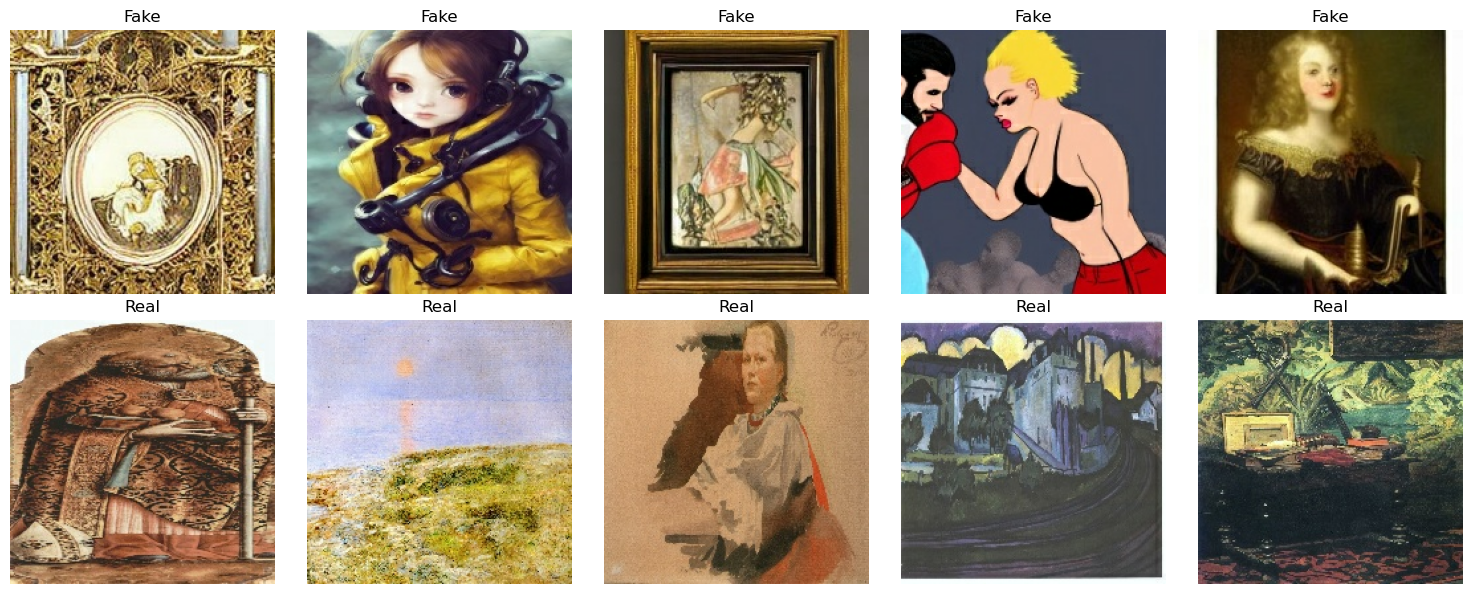

In [6]:
fake_images = []
real_images = []
num_images = 5


for images, labels in train_dataset:
    for i in range(images.shape[0]):
        # get the label value from the array
        label_index = int(labels[i].numpy())
        image = images[i].numpy()

        if class_names[label_index] == 'fake' and len(fake_images) < num_images:
            fake_images.append(image)
        elif class_names[label_index] == 'real' and len(real_images) < num_images:
            real_images.append(image)

    # break if needed
    if len(fake_images) >= num_images and len(real_images) >= num_images:
        break


fig, axes = plt.subplots(2, num_images, figsize=(15, 6))

for i in range(num_images):
    axes[0, i].imshow(fake_images[i] )
    axes[0, i].axis('off')
    axes[0, i].set_title('Fake')

    axes[1, i].imshow(real_images[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Real')

plt.tight_layout()
plt.show()

### Baseline model and training

For the baseline model on the Art dataset, we use a CNN with three convolutions with pooling blocks (32→64→128 filters), followed by a flatten, a 128-unit dense layer with 50% dropout, and a sigmoid output for binary classification. 

It’s compiled with Adam on binary crossentropy, tracks accuracy, precision, recall, and AUC, and is trained up to 10 epochs with early stopping and model checkpointing.

In [7]:
def create_baseline_model(input_shape=(200, 200, 3)):
    inputs = Input(shape=input_shape)

    # 1st convo
    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)

    # 2nd convo
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # 3rd convo
    x = Conv2D(128, (3, 3), activation='relu',
                      name='last_conv_layer')(x)
    x = MaxPooling2D((2, 2))(x)

    # flatten the output
    x = Flatten()(x)

    # fully connected layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    #  output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)
    loss = 'binary_crossentropy'

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=loss,
        metrics=['accuracy', Precision(), Recall(), AUC()]
    )

    return model


model = create_baseline_model(
        input_shape=(200, 200, 3)
)

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 198, 198, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 48, 48, 64)        0         
 g2D)                                                            
                                                                 
 last_conv_layer (Conv2D)    (None, 46, 46, 128)       73856 

In [ ]:
# check for existing weights
history = None
if os.path.exists(f"{weigths_path}/art_baseline_model.h5"):
    print("Loading existing model weights...")
    model.load_weights(f"{weigths_path}/art_baseline_model.h5")
else:
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=f"{weigths_path}/art_baseline_model.h5",
                save_best_only=True,
                monitor='val_loss',
                mode='min'
            )
        ]
    )

    # save the model weights
    model.save(f"{weigths_path}/art_baseline_model.h5")

Epoch 1/10


2025-04-27 23:54:46.409795: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-04-27 23:54:49.333873: I external/local_xla/xla/service/service.cc:168] XLA service 0x14d87d26ea50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-27 23:54:49.333910: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-04-27 23:54:49.338820: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745812489.407570    7569 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2694/2694 [==============================] - ETA: 0s - loss: 0.1996 - accuracy: 0.9236 - precision: 0.9264 - recall: 0.9010 - auc: 0.9756

/shared/courseSharedFolders/142601outer/142601/cs109b/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2694/2694 [==============================] - 118s 42ms/step - loss: 0.1996 - accuracy: 0.9236 - precision: 0.9264 - recall: 0.9010 - auc: 0.9756 - val_loss: 0.0965 - val_accuracy: 0.9651 - val_precision: 0.9794 - val_recall: 0.9419 - val_auc: 0.9945
Epoch 2/10
2694/2694 [==============================] - 76s 28ms/step - loss: 0.1086 - accuracy: 0.9614 - precision: 0.9602 - recall: 0.9534 - auc: 0.9919 - val_loss: 0.1077 - val_accuracy: 0.9647 - val_precision: 0.9826 - val_recall: 0.9377 - val_auc: 0.9933
Epoch 3/10
2694/2694 [==============================] - 79s 29ms/step - loss: 0.0793 - accuracy: 0.9731 - precision: 0.9727 - recall: 0.9671 - auc: 0.9951 - val_loss: 0.0553 - val_accuracy: 0.9824 - val_precision: 0.9797 - val_recall: 0.9809 - val_auc: 0.9972
Epoch 4/10
2694/2694 [==============================] - 78s 29ms/step - loss: 0.0556 - accuracy: 0.9813 - precision: 0.9821 - recall: 0.9760 - auc: 0.9973 - val_loss: 0.0653 - val_accuracy: 0.9813 - val_precision: 0.9894 - val_rec

In [9]:
if history:
    plot_training_history(history)
else:
    # show the image saved in memory 
    history_image_path = "../images/art_baseline_history.png"
    
    # show image 
    plt.figure(figsize=(14, 8))
    img = plt.imread(history_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    

test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(
    test_dataset, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")



Test accuracy: 0.9890
Test precision: 0.9920
Test recall: 0.9833
Test AUC: 0.9981


Our baseline model has a test accuracy of 0.9810 which is already quite big a baseline model. The goal for our refined model would have to be the closest a possible to the 100% accuracy without over-fitting.

### Model evaluation

#### Saliency Map and Grad-CAM heatmap

/tmp/ipykernel_37724/2470748013.py:214: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(labels[i].numpy())


Last convolutional layer name: last_conv_layer


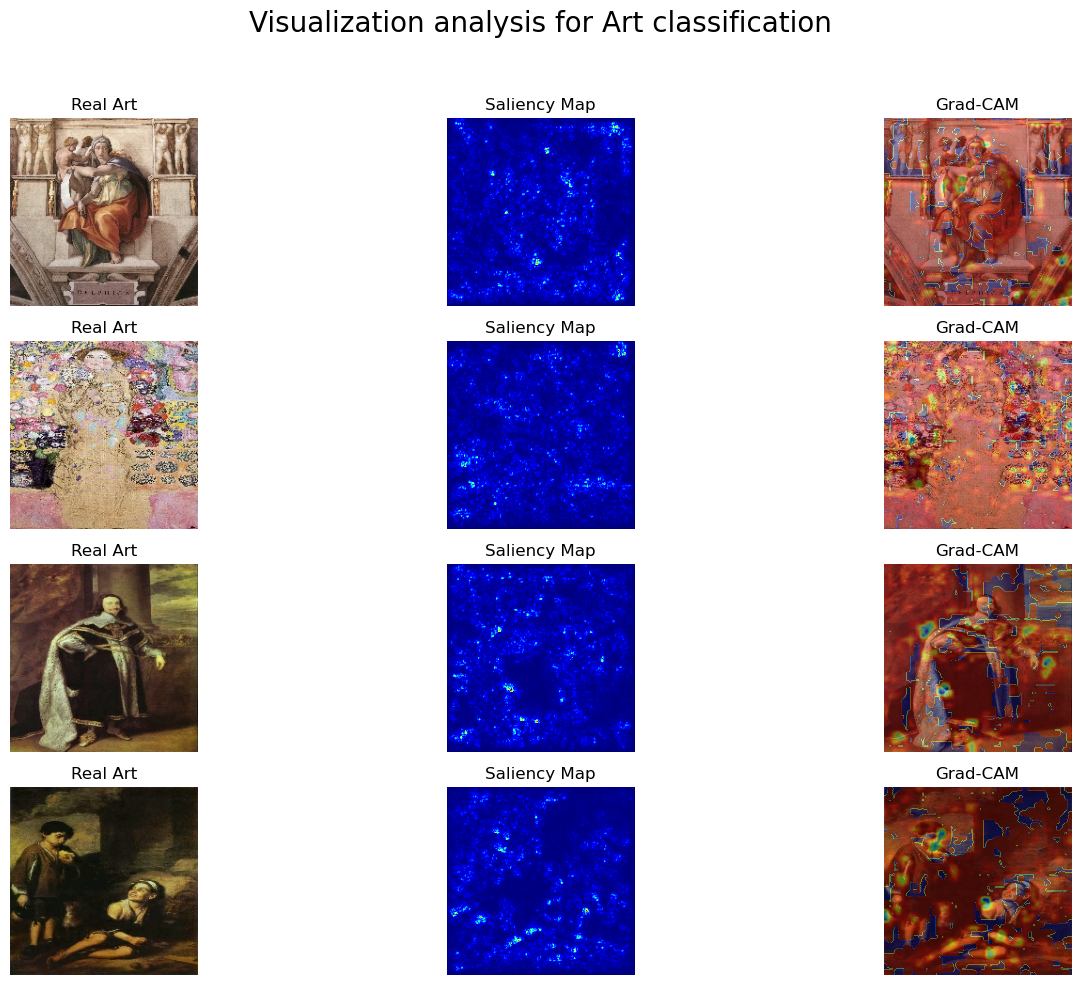

In [10]:
sample_images, sample_labels = get_sample_images(test_dataset, num_samples=5)

# we need to extract the name from the model
last_conv_layer_name = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name

print(f"Last convolutional layer name: {last_conv_layer_name}")

# Grad-CAM and Saliency maps 
plt.figure(figsize=(15, 10))
plt.suptitle("Visualization analysis for Art classification", fontsize=20)

for i, (img, label) in enumerate(zip(sample_images[:4], sample_labels[:4])):
    # original image
    plt.subplot(4, 3, i*3+1)
    plt.imshow(img)
    plt.title(f"{'Real' if label==1 else 'Fake'} Art")
    plt.axis('off')
    
    # Saliency map
    saliency = compute_saliency_map(model, img, target_class=label)
    plt.subplot(4, 3, i*3+2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency Map")
    plt.axis('off')
    
    # Grad-CAM
    plt.subplot(4, 3, i*3+3)
    plt.imshow(img)
    
    # Grad-CAM heatmap
    img_tensor = np.expand_dims(img, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0] 
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    heatmap = np.uint8(255* heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    
    # use an overlay heatmap on the original image
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title("Grad-CAM")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#### Confusion matrix

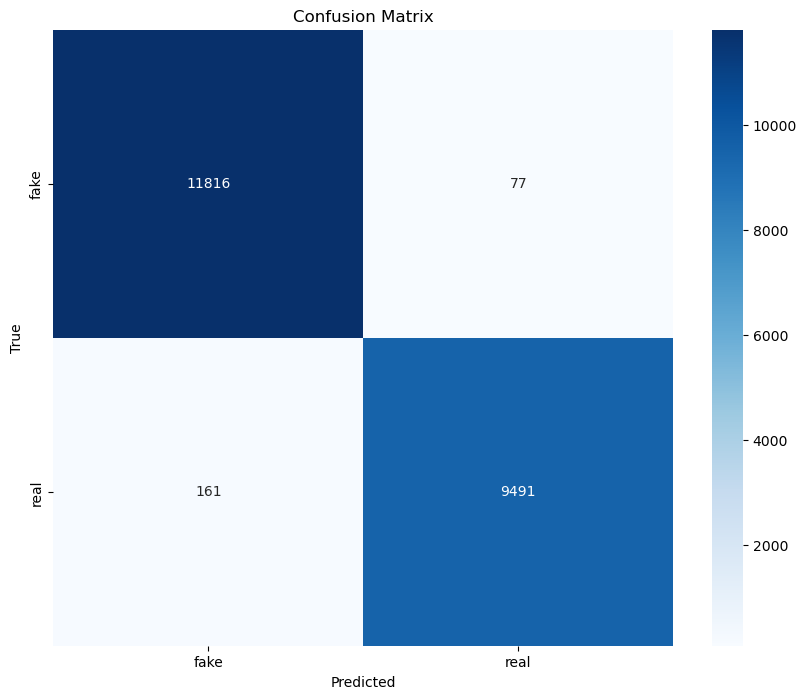

Classification report:

              precision    recall  f1-score   support

        fake       0.99      0.99      0.99     11893
        real       0.99      0.98      0.99      9652

    accuracy                           0.99     21545
   macro avg       0.99      0.99      0.99     21545
weighted avg       0.99      0.99      0.99     21545

Metrics:
True negatives (correctly identified fake): 11816
False positives (fake identified as real): 77
False negatives (real identified as fake): 161
True positives (correctly identified real): 9491
Precision: 0.9920
Recall: 0.9833
F1 score: 0.9876


In [11]:
y_pred, y_true = get_predictions_and_labels(test_dataset, model)
cm = confusion_matrix(y_true, y_pred)

# plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification report:\n")
print(report)

# metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Metrics:")
print(f"True negatives (correctly identified fake): {tn}")
print(f"False positives (fake identified as real): {fp}")
print(f"False negatives (real identified as fake): {fn}")
print(f"True positives (correctly identified real): {tp}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")

### Analysis on misclassfied examples with Grad-cam and Saliency MAP

/tmp/ipykernel_37724/2470748013.py:291: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[i].numpy())


Found 920 confident correct predictions
Found 5 incorrect predictions
Found 5 uncertain predictions

Visualizing incorrect predictions:


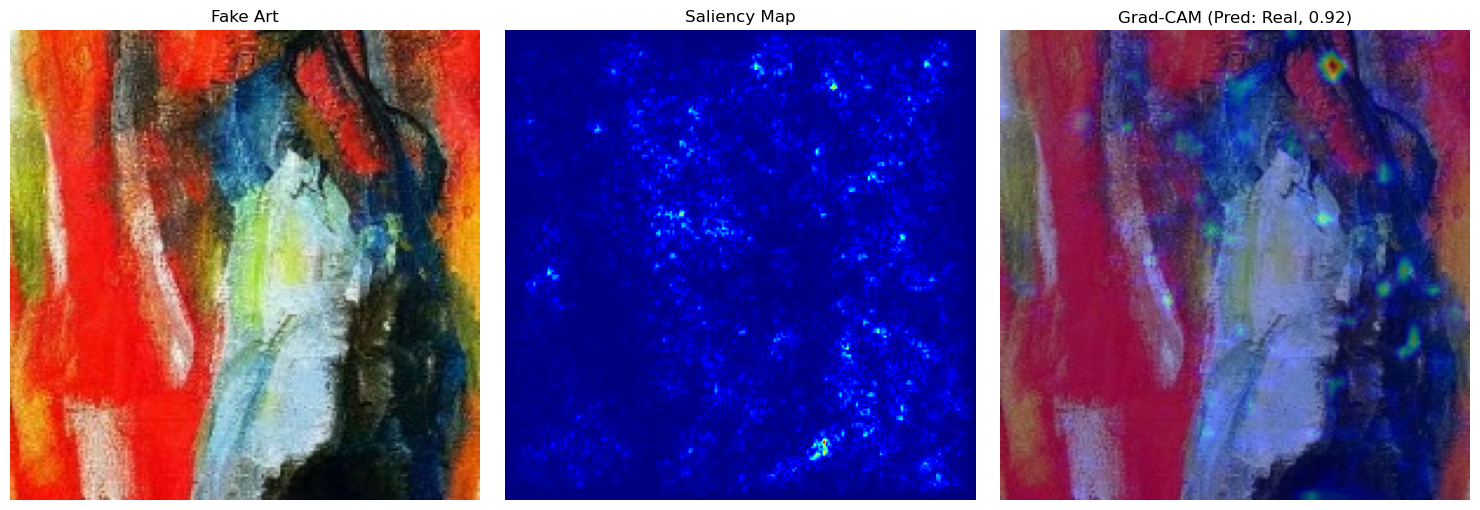

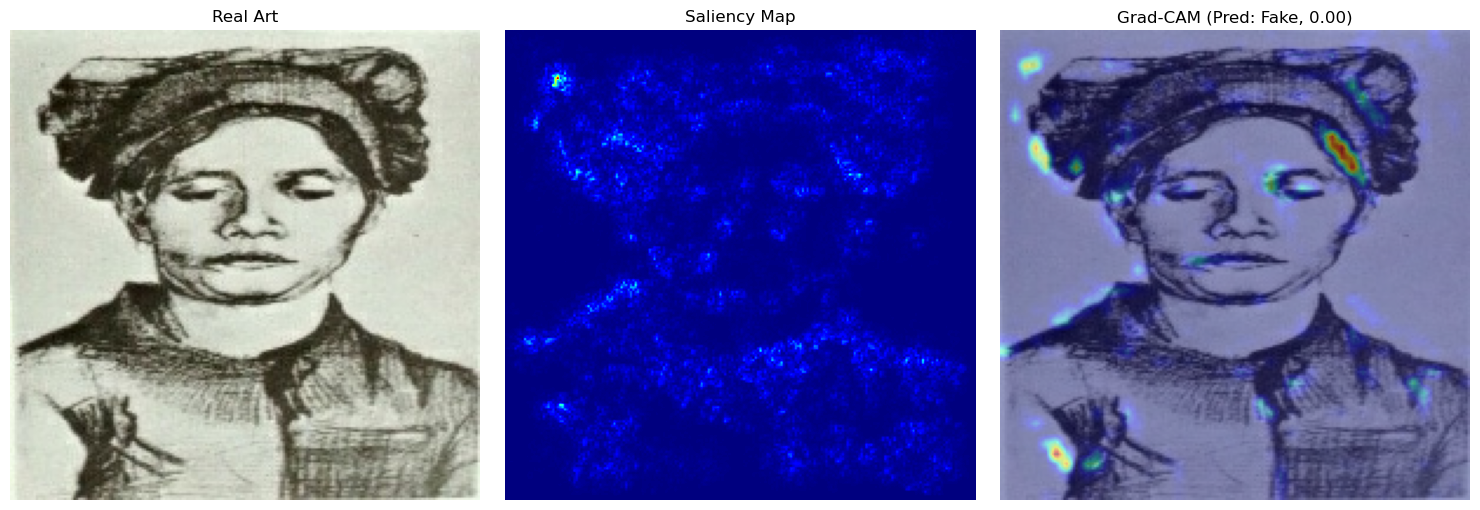


Visualizing uncertain predictions:


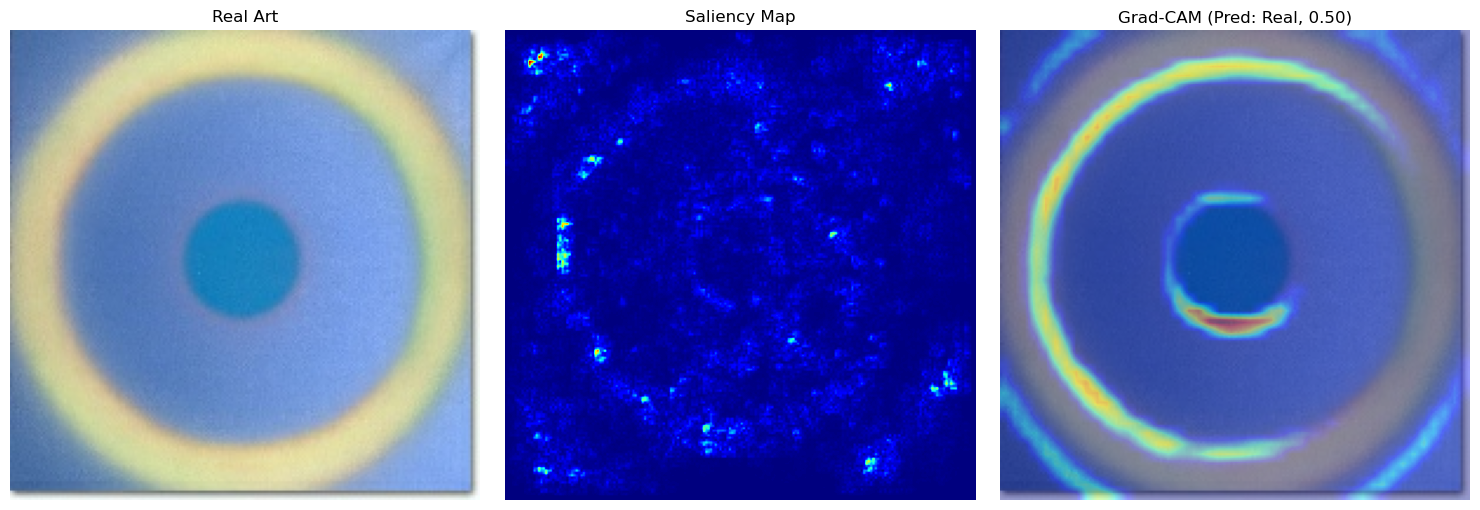

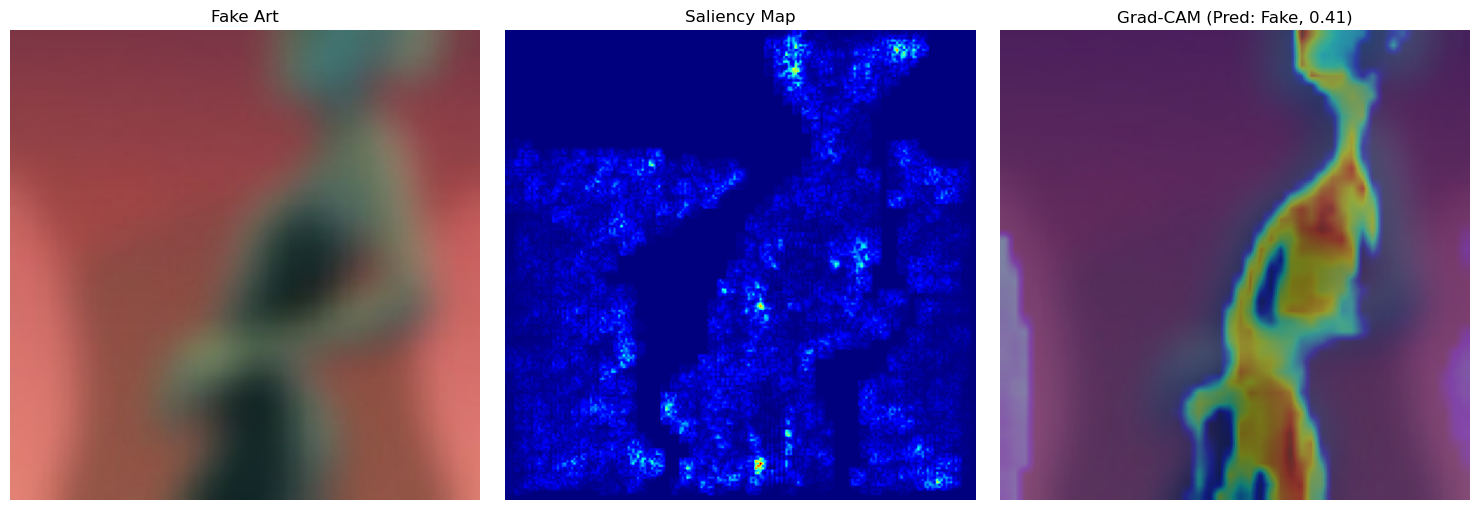

In [12]:
# get misclassified and confident predictions
correct_confident, incorrect, unsure = find_interesting_examples(test_dataset, model)

print(f"Found {len(correct_confident)} confident correct predictions")
print(f"Found {len(incorrect)} incorrect predictions")
print(f"Found {len(unsure)} uncertain predictions")

# plot
print("\nVisualizing incorrect predictions:")
for img, true_label, pred_prob in incorrect[:2]:
    visualize_single_image(model, img, last_conv_layer_name, true_label)

print("\nVisualizing uncertain predictions:")
for img, true_label, pred_prob in unsure[:2]:
    visualize_single_image(model, img, last_conv_layer_name, true_label)

#### ROC and AUC

Area Under the ROC Curve (AUC): 0.998875
Optimal threshold: 0.3314


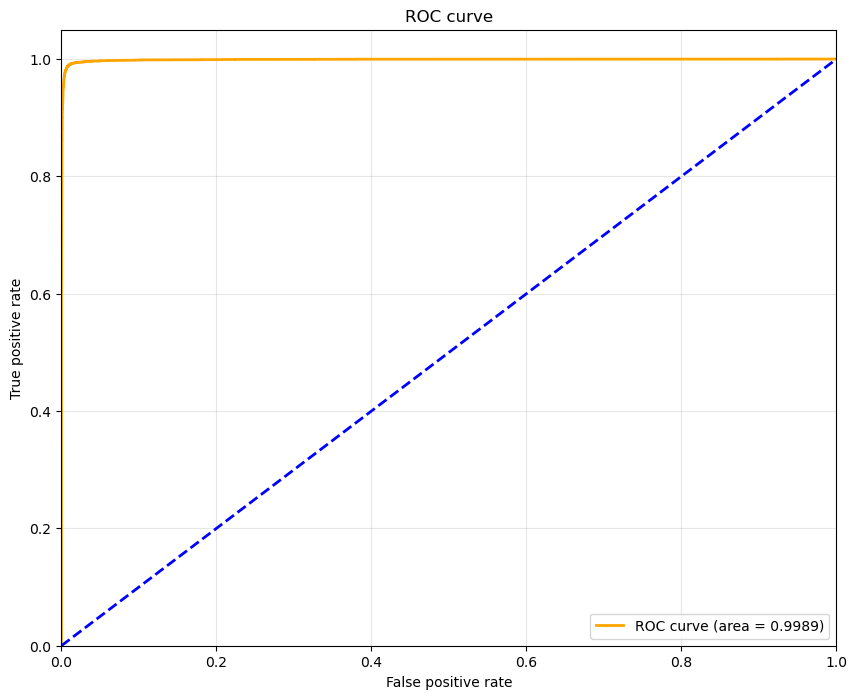

In [13]:
y_prob, y_true = get_probabilities_and_labels(test_dataset, model)

# roc and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

print(f"Area Under the ROC Curve (AUC): {roc_auc:.6f}")

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.4f}")

### Performances analysis

Our  baseline CNN is almost perfect at detecting AI-made art: it scored 98.90% accuracy on over 21500 test images, with only 161 fake‐as‐real and 77 real‐as‐fake mistakes. Its precision of 0.9920, recall of 0.9833, and F1‐score of 0.9876 show it rarely misses or mislabels, hence a good model

We use heatmaps and Grad-CAM to explain how it works. On fake images, it lights up odd textures and warped edges that AI tools often leave behind (that can be hard to see to the naked eye). On real paintings, its attention is softer and spread over genuine brushstrokes and natural color shifts